In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [ ]:
# Matrix norms
x = torch.tensor([1.0, 2.0, 3.0])
print(x.norm(2))

y = torch.tensor([[1.0, 2.0, 3.0], 
                  [4.0, 5.0, 6.0]])
print(y.shape)
print(y.norm(2))

tensor(3.7417)
tensor([1., 2., 3., 4., 5., 6.])
torch.Size([2, 3])
tensor(9.5394)


In [43]:
# Exploring mean and std

x = torch.randn(100)
print("Max val = ", x.max())
print("Min val = ", x.min())
print("Mean val = ", x.mean())
print("Std val = ", x.std())

# Now, scale and add
new_mean = 4.5
new_std = 2.2

x = x*new_std + new_mean
print("="*60)
print("After scaling and adding")
print("="*60)
print("Max val = ", x.max())
print("Min val = ", x.min())
print("Mean val = ", x.mean())
print("Std val = ", x.std())

Max val =  tensor(2.2763)
Min val =  tensor(-2.4117)
Mean val =  tensor(0.0936)
Std val =  tensor(0.9808)
After scaling and adding
Max val =  tensor(9.5078)
Min val =  tensor(-0.8058)
Mean val =  tensor(4.7058)
Std val =  tensor(2.1578)


Mean and std befor normalization  [3.1241555213928223, 2.860445022583008, 3.3503971099853516] [1.9154249429702759, 2.0590553283691406, 2.169508457183838]
Xi shape =  torch.Size([3, 10])
Xi_norm shape =  torch.Size([3, 10])
Mean and std after normalization  [3.5762788286319847e-08, 2.3841858265427618e-08, 5.9604645663569045e-09] [1.0540908575057983, 1.0540910959243774, 1.0540913343429565]


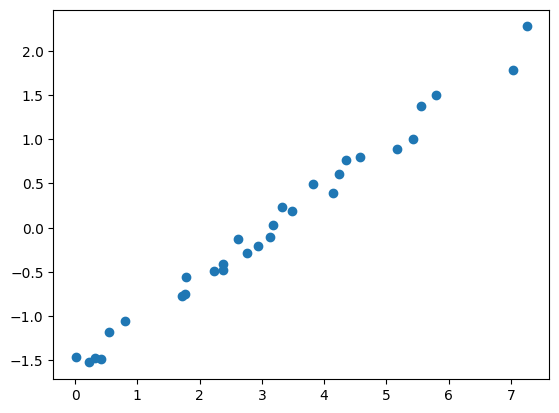

In [ ]:
# Here we are applying norm in dim 1, i.e across every row
in_f = 3 
out_f = 10
Xi = torch.randn((in_f, out_f))
Xi = Xi * 2 + 3

print("Mean and std befor normalization ", torch.mean(Xi, axis=1).detach().tolist(), torch.std(Xi, axis=1).detach().tolist())

layer_norm = nn.LayerNorm(out_f)
Xi_norm = layer_norm(Xi)
print("Xi shape = ", Xi.shape)
print("Xi_norm shape = ", Xi_norm.shape)
print("Mean and std after normalization ", torch.mean(Xi_norm, axis=1).detach().tolist(), torch.std(Xi_norm, axis=1).detach().tolist())

plt.scatter(Xi.detach().flatten(), Xi_norm.detach().flatten())

Xi shape =  torch.Size([3, 10])
Xi_norm shape =  torch.Size([3, 10])
Mean and std after normalization axis 0 [3.089689254760742, 6.1915974617004395, 4.062066555023193, 5.8380584716796875, 1.9363664388656616, 9.230052947998047, 3.5735905170440674, 4.7768073081970215, 4.325024604797363, 6.976745128631592] [3.632216215133667, 2.2238380908966064, 1.057111382484436, 2.8460633754730225, 1.6763499975204468, 3.384789228439331, 3.1849417686462402, 3.5267293453216553, 1.3065179586410522, 2.9190750122070312]
Mean and std after normalization axis 1 [5.019158840179443, 4.61462926864624, 5.366211414337158] [2.9382448196411133, 3.1585724353790283, 3.3280067443847656]


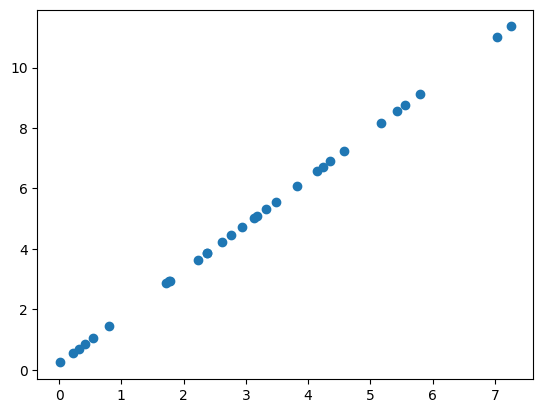

In [74]:
layer_norm1 = nn.LayerNorm((in_f, out_f))
layer_norm1.weight.data = torch.ones(in_f, out_f) * 3
layer_norm1.bias.data = torch.ones(in_f, out_f) * 5
Xi_norm = layer_norm1(Xi)
print("Xi shape = ", Xi.shape)
print("Xi_norm shape = ", Xi_norm.shape)
print("Mean and std after normalization axis 0", torch.mean(Xi_norm, axis=0).detach().tolist(), torch.std(Xi_norm, axis=0).detach().tolist())
print("Mean and std after normalization axis 1", torch.mean(Xi_norm, axis=1).detach().tolist(), torch.std(Xi_norm, axis=1).detach().tolist())

plt.scatter(Xi.detach().flatten(), Xi_norm.detach().flatten())
